In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

2025-03-20 15:10:22.855491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742492422.907359     445 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742492422.922942     445 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:
print(jax.default_backend())

gpu


In [5]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [6]:
t0, tfinal = 0.0, 1.0

In [7]:
def TodaLatt(w, t):
    
    p1, p2, p3, q1, q2, q3 = w

    p1_t = -jnp.exp(q1 - q2) + jnp.exp(q3 - q1)
    q1_t = p1

    p2_t = jnp.exp(q1 - q2) - jnp.exp(q2 - q3)
    q2_t = p2

    p3_t = jnp.exp(q2 - q3) - jnp.exp(q3 - q1)
    q3_t = p3

    dwdt = [p1_t, p2_t, p3_t, q1_t, q2_t, q3_t]

    return dwdt

In [8]:
@jax.jit
def calc_H(p1, p2, p3, q1, q2, q3) :

    H = (p1**2)/2 + (p2**2)/2 + (p3**2)/2 + jnp.exp(q1 - q2) + jnp.exp(q2 - q3) + jnp.exp(q3 - q1)

    return H

In [9]:
Hmax = 5/2 + np.exp(2) + np.exp(-2)
Hmin = 3.0

print(Hmin, Hmax)

3.0 10.024391382167263


In [10]:
@jax.jit
def calc_ab(p1, p2, p3, q1, q2, q3) :

    a1 = -0.5*p1
    a2 = -0.5*p2
    a3 = -0.5*p3

    b1 = 0.5*jnp.exp(0.5*(q1-q2))
    b2 = 0.5*jnp.exp(0.5*(q2-q3))
    b3 = 0.5*jnp.exp(0.5*(q3-q1))

    return a1, a2, a3, b1, b2, b3

In [11]:
@jax.jit
def calc_evals(a1, a2, a3, b1, b2, b3) :
    
    main_diag = jnp.array([a1, a2, a3])
    sub_diag = jnp.array([b1, b2])
    super_diag = jnp.array([b1, b2])
    subsub_diag = jnp.array([b3])
    supersuper_diag = jnp.array([b3])

    L_main = jnp.diag(main_diag)
    L_sub = jnp.diag(sub_diag, k=-1)
    L_super = jnp.diag(super_diag, k=1)
    L_subsub = jnp.diag(subsub_diag, k=-2)
    L_supersuper = jnp.diag(supersuper_diag, k=2)

    L = L_main + L_sub + L_super + L_subsub + L_supersuper

    evals, _ = jnp.linalg.eigh(L)

    return evals

In [12]:
@jax.jit
def calc_evals_pq(p1, p2, p3, q1, q2, q3) :

    a1, a2, a3, b1, b2, b3 = calc_ab(p1, p2, p3, q1, q2, q3)
    
    a1 = jnp.reshape(a1, (-1,))
    a2 = jnp.reshape(a2, (-1,))
    a3 = jnp.reshape(a3, (-1,))
    b1 = jnp.reshape(b1, (-1,))
    b2 = jnp.reshape(b2, (-1,))
    b3 = jnp.reshape(b3, (-1,))
    
    evals = jax.vmap(calc_evals, (0, 0, 0, 0, 0, 0), 0)(a1, a2, a3, b1, b2, b3)
    evals = jnp.reshape(evals, (-1,))
    
    return evals
    

In [13]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

    p1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Hs = calc_H(p1s, p2s, p3s, q1s, q2s, q3s)

    evals = jax.vmap(calc_evals_pq, (0), 0)(p1s, p2s, p3s, q1s, q2s, q3s)
    Hs_test = 2*(evals[:, :1]**2 + evals[:, 1:2]**2 + evals[:, 2:]**2)

    ode_points = np.column_stack((ode_points, Hs, evals))
    zsensors = np.column_stack((p1s, p2s, p3s, q1s, q2s, q3s))
    
    return (ode_points, zsensors)

In [14]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 5) (1000, 6)


In [15]:
Hmax_act = np.max(de_points[:, 1])
Hmin_act = np.min(de_points[:, 1])

print(Hmax, Hmax_act)
print(Hmin, Hmin_act)

10.024391382167263 8.709369833294234
3.0 3.104420625374381


In [16]:
# from scipy.optimize import minimize

# def funcmin(x):

#     return (x[0]**2)/2 + (x[1]**2)/2 + (x[2]**2)/2 + jnp.exp(x[3] - x[4]) + jnp.exp(x[4] - x[5]) + jnp.exp(x[5] - x[3])

# def funcmax(x):

#     return -1.0*((x[0]**2)/2 + (x[1]**2)/2 + (x[2]**2)/2 + jnp.exp(x[3] - x[4]) + jnp.exp(x[4] - x[5]) + jnp.exp(x[5] - x[3]))

# # Domain boundaries (x and y range from -5 to 5)
# bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]

# # Initial guess for the optimization algorithm
# initial_guess = [0.5, -0.5, 0.5, -0.5, 0.5, -0.5]

# # Minimize the function
# resultmin = minimize(funcmin, initial_guess, bounds=bounds)
# resultmax = minimize(funcmax, initial_guess, bounds=bounds)

# # Print the result
# print("Minimum value found:", resultmin.fun)
# print("At point:", resultmin.x)

# print("Maximum value found:", resultmax.fun)
# print("At point:", resultmax.x)

# print(5/2 + np.exp(2) + np.exp(-2))

In [17]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [18]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [19]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [20]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(6*self.units)(b)
    return out

In [21]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    q1_0 = u[:, 3:4]
    q2_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, q1_0, q2_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q1 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q2 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_q1 = branch_net[:, 3*self.units:4*self.units]
    branch_q2 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, p2, p3, q1, q2, q3

In [22]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    q1_0 = z[:, 3:4]
    q2_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    p3 = var(tHE, z, 2, params)
    q1 = var(tHE, z, 3, params)
    q2 = var(tHE, z, 4, params)
    q3 = var(tHE, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dp3_tHE = var_t(tHE, z, 2, params)
    dq1_tHE = var_t(tHE, z, 3, params)
    dq2_tHE = var_t(tHE, z, 4, params)
    dq3_tHE = var_t(tHE, z, 5, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + \
                q2_t_loss_w*q2_t_loss + p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(loss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [23]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [24]:
deeponet = DeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0)
u_init = jnp.full((10, 6), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [25]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

26640


In [26]:
epochs = 3000
params, loss = train_network(params, de_points, zsensors, epochs)


batch size: 100


I0000 00:00:1742492474.761667     445 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 467 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Loss in epoch 0: 1.3272451179931233
Loss in epoch 100: 0.010971468491226804
Loss in epoch 200: 0.004642797294254323
Loss in epoch 300: 0.0030177678105898255
Loss in epoch 400: 0.003027975585191092
Loss in epoch 500: 0.002138257863638862
Loss in epoch 600: 0.0013197089032239398
Loss in epoch 700: 0.0009628498964517222
Loss in epoch 800: 0.001258840395606365
Loss in epoch 900: 0.001599220709812268
Loss in epoch 1000: 0.0008071023141846419
Loss in epoch 1100: 0.0005993053265433286
Loss in epoch 1200: 0.0009644120943900855
Loss in epoch 1300: 0.0004329222890542514
Loss in epoch 1400: 0.0007397373581402394
Loss in epoch 1500: 0.00035256621895404626
Loss in epoch 1600: 0.0008528645146312541
Loss in epoch 1700: 0.0005721889700530524
Loss in epoch 1800: 0.001181030046306493
Loss in epoch 1900: 0.0004332620277858254
Loss in epoch 2000: 0.00021377681253314712
Loss in epoch 2100: 0.00025227793246867326
Loss in epoch 2200: 0.0005195250708146864
Loss in epoch 2300: 0.00021460310472802172
Loss in ep

In [66]:
#params_5000ep = copy.deepcopy(params)

# tree_info, shapes, params_flat = flatten_pytree(params)
# jnp.save("P_t1.0_5000_ep_Toda3", params_flat)

tree_info, shapes, _ = flatten_pytree(params)
params_flat = jnp.load("P_t1.0_5000_ep_Toda3.npy")
params = reconstruct_pytree(tree_info, shapes, params_flat)

In [67]:
# start = 0
# stop = 5000

# plt.semilogy(loss[start:stop])
# plt.legend(['Vanilla DN'])
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error for Vanilla DeepONet")
# plt.grid()
# #plt.savefig('Toda3_vanilla_loss_5000ep.png')

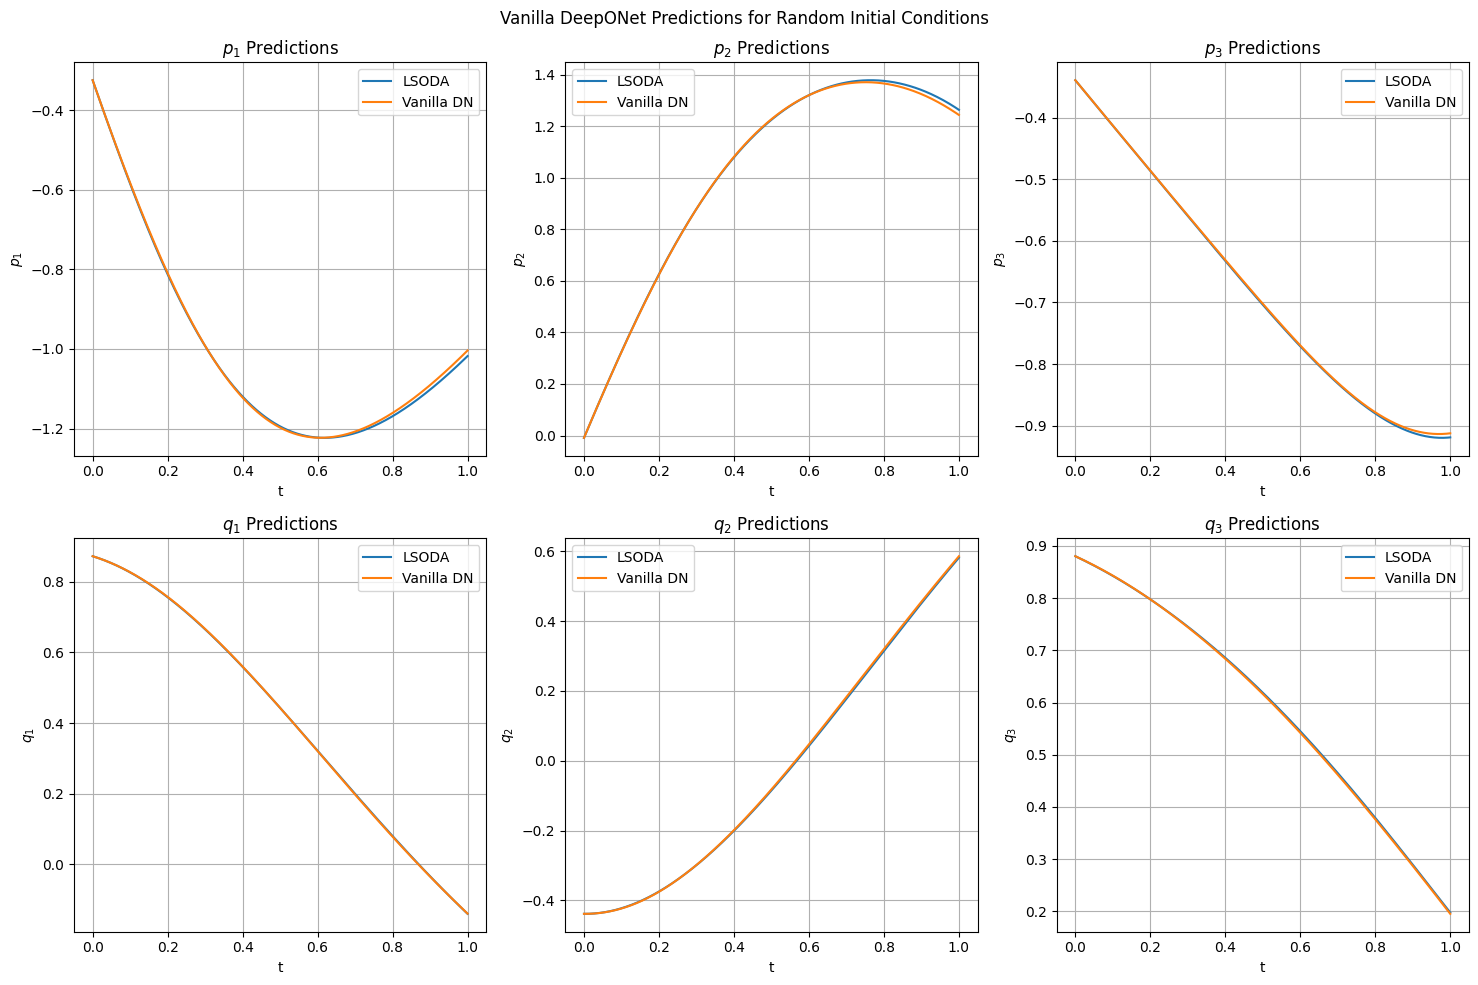

In [68]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]


data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)

E_model = np.column_stack([e1_init, e2_init, e3_init])
E_model = np.reshape(E_model, (-1,))
E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
tHE_model = np.column_stack([t, H_model, E_model])

p1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 0, params)
p2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 1, params)
p3 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 2, params)
q1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 3, params)
q2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 4, params)
q3 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 5, params)



data_rk = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t
    
sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)


fig = plt.figure(figsize=(15, 10))
fig.suptitle("Vanilla DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t, p1_rk)
plt.plot(t, p1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t, p2_rk)
plt.plot(t, p2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t, p3_rk)
plt.plot(t, p3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t, q1_rk)
plt.plot(t, q1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t, q2_rk)
plt.plot(t, q2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t, q3_rk)
plt.plot(t, q3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

#fig.savefig("Toda3_vanilla_preds_5000ep.png")

In [27]:
# tree_info, shapes, params_flat = flatten_pytree(params)
# jnp.save("P_t1.0_5000_ep_Toda3", params_flat)

# tree_info, shapes, _ = flatten_pytree(params)
# params_flat = jnp.load("P_t0.5_1000_5000_ep_Toda3.npy")
# params = reconstruct_pytree(tree_info, shapes, params_flat)

In [28]:
class EDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    q1_0 = u[:, 3:4]
    q2_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, q1_0, q2_0, q3_0, H_0_norm))

    b = t_0_norm
    # b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q1 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q2 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_q1 = branch_net[:, 3*self.units:4*self.units]
    branch_q2 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, p2, p3, q1, q2, q3

In [29]:
@partial(jax.jit, static_argnums=(2,))
def Evar_model(t, z, component, params):
  return Edeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Evar(t, z, component, params):
  return jax.vmap(Evar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Evar_t(t, z, component, params):
  return jax.vmap(jax.grad(Evar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def Eloss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    q1_0 = z[:, 3:4]
    q2_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = Evar(tHE, z, 0, params)
    p2 = Evar(tHE, z, 1, params)
    p3 = Evar(tHE, z, 2, params)
    q1 = Evar(tHE, z, 3, params)
    q2 = Evar(tHE, z, 4, params)
    q3 = Evar(tHE, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = Evar_t(tHE, z, 0, params)
    dp2_tHE = Evar_t(tHE, z, 1, params)
    dp3_tHE = Evar_t(tHE, z, 2, params)
    dq1_tHE = Evar_t(tHE, z, 3, params)
    dq2_tHE = Evar_t(tHE, z, 4, params)
    dq3_tHE = Evar_t(tHE, z, 5, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + \
                q2_t_loss_w*q2_t_loss + p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def Etrain_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(Eloss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Eoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [30]:
def Etrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = Etrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = Eoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [31]:
Edeeponet = EDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0)
u_init = jnp.full((10, 6), 1.0)

Eparams = Edeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [32]:
Eparam_count = sum(x.size for x in jax.tree.leaves(Eparams))
print(Eparam_count)

26640


In [33]:
#Eloss_norm_tr = copy.deepcopy(Eloss)
#Eloss_norm_br= copy.deepcopy(Eloss)
#print(Eloss_norm_tr.shape)

batch size: 100
Loss in epoch 0: 2.001499036336841
Loss in epoch 100: 0.015947418530081147
Loss in epoch 200: 0.01075768987577258
Loss in epoch 300: 0.0038873178760908717
Loss in epoch 400: 0.0028447477383546555
Loss in epoch 500: 0.0026129187514687853
Loss in epoch 600: 0.0020947429648215054
Loss in epoch 700: 0.0014663590815414652
Loss in epoch 800: 0.0017448424593735313
Loss in epoch 900: 0.0008121852875592374
Loss in epoch 1000: 0.0007975956425646022
Loss in epoch 1100: 0.0013409810653865909
Loss in epoch 1200: 0.001823004673526313
Loss in epoch 1300: 0.0005287869914521696
Loss in epoch 1400: 0.001158297763372314
Loss in epoch 1500: 0.0008240905166262578
Loss in epoch 1600: 0.0005609636965419925
Loss in epoch 1700: 0.00037948688308762717
Loss in epoch 1800: 0.00042299509614072706
Loss in epoch 1900: 0.0005523327441757761
Loss in epoch 2000: 0.0006748282985055784
Loss in epoch 2100: 0.00035851872889319065
Loss in epoch 2200: 0.0006218389719444074
Loss in epoch 2300: 0.00031033180999

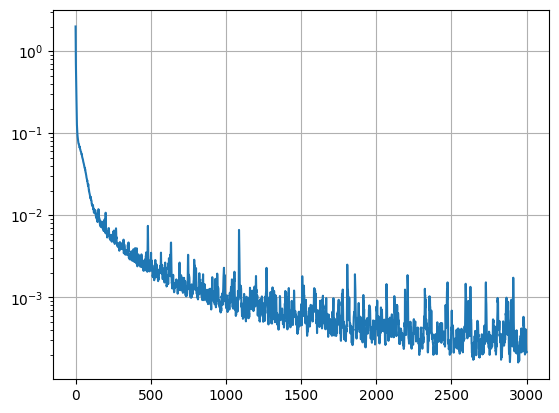

In [34]:
epochs = 3000
Eparams, Eloss = Etrain_network(Eparams, de_points, zsensors, epochs)

plt.semilogy(Eloss)
plt.grid()

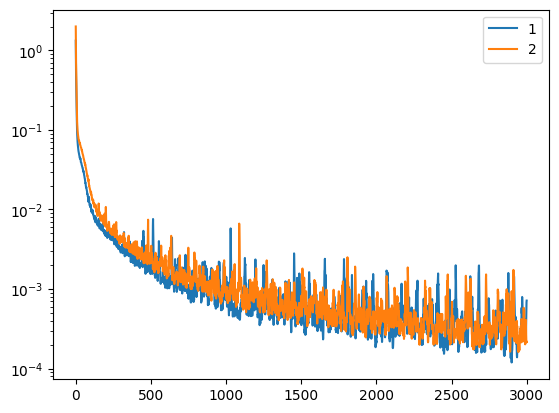

In [38]:
# Eloss_nonnorm = copy.deepcopy(Eloss)
# Eloss_norm = copy.deepcopy(Eloss)

plt.semilogy(loss)
plt.semilogy(Eloss)
plt.legend(['1', '2'])

In [78]:
# start = 0
# stop = 1000

# plt.semilogy(loss[start:stop])
# plt.semilogy(Eloss_nonnorm[start:stop])
# plt.semilogy(Eloss_norm[start:stop])
# plt.legend(['Vanilla DN', 'Extended DN w/o Normalization', 'Extended DN w/ Normalization'])
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error for Extended DeepONet")
# plt.grid()
# #plt.savefig('Toda3_loss_extended_normalizedH_1000ep.png')

In [79]:
# tree_info, shapes, Eparams_flat = flatten_pytree(Eparams)
# jnp.save("E_t0.5_1000_1000_ep_Toda3", Eparams_flat)

# tree_info, shapes, _ = flatten_pytree(Eparams)
# Eparams_flat = jnp.load("E_t0.5_1000_5000_ep_Toda3.npy")
# Eparams = reconstruct_pytree(tree_info, shapes, Eparams_flat)

In [80]:
# @jax.jit
# def loss_fun(args, e_0) :

#     args = jnp.reshape(args, (-1,))
#     e_0 = jnp.reshape(e_0, (-1,))

#     p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
#     e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]

#     a1, a2, a3, b1, b2, b3 = calc_ab(args)

#     args_new = (a1, a2, a3, b1, b2, b3)

#     evals = calc_evals(a1, a2, a3, b1, b2, b3)
    
#     e1 = evals[0]
#     e2 = evals[1]
#     e3 = evals[2]

#     f1 = (e1 - e1_0)**2
#     f2 = (e2 - e2_0)**2
#     f3 = (e3 - e3_0)**2

#     f_arr = jnp.array([[f1], [f2], [f3]])
#     norm_f = jnp.linalg.norm(f_arr, ord = jnp.inf)

#     # f = f1 + f2 + f3

#     return norm_f
#     #return jnp.array([[f]])


# @jax.jit
# def get_derivs(args, e_0, e) :

#     a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]

#     dF_e = 3*e**2 - 2*(a1 + a2 + a3)*e + (a1*a2 + a2*a3 + a1*a3 - b1**2 - b2**2 - b3**2)
#     dF_a1 = -e**2 + (a2 + a3)*e - (a2*a3 - b2**2)
#     dF_a2 = -e**2 + (a1 + a3)*e - (a1*a3 - b3**2)
#     dF_a3 = -e**2 + (a1 + a2)*e - (a1*a2 - b1**2)
#     dF_b1 = -2*b1*e - (-2*a3*b1 + 2*b2*b3)
#     dF_b2 = -2*b2*e - (-2*a1*b2 + 2*b1*b3)
#     dF_b3 = -2*b3*e - (-2*a2*b3 + 2*b1*b2)

#     de_a1 = -dF_a1/dF_e
#     de_a2 = -dF_a2/dF_e
#     de_a3 = -dF_a3/dF_e
#     de_b1 = -dF_b1/dF_e
#     de_b2 = -dF_b2/dF_e
#     de_b3 = -dF_b3/dF_e

#     df_a1 = 2*(e - e_0)*de_a1
#     df_a2 = 2*(e - e_0)*de_a2
#     df_a3 = 2*(e - e_0)*de_a3
#     df_b1 = 2*(e - e_0)*de_b1
#     df_b2 = 2*(e - e_0)*de_b2
#     df_b3 = 2*(e - e_0)*de_b3

#     df_x = (df_a1, df_a2, df_a3, df_b1, df_b2, df_b3)

#     return df_x


# # @jax.jit
# # def grad_loss_fun(args, e_0) :

# #     args = jnp.reshape(args, (-1,))
# #     e_0 = jnp.reshape(e_0, (-1,))

# #     p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
# #     e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]

# #     a1, a2, a3, b1, b2, b3 = calc_ab(args)
    
# #     args_new = (a1, a2, a3, b1, b2, b3)

# #     evals = calc_evals(a1, a2, a3, b1, b2, b3)
    
# #     e1 = evals[0]
# #     e2 = evals[1]
# #     e3 = evals[2]

# #     df1_a1, df1_a2, df1_a3, df1_b1, df1_b2, df1_b3 = get_derivs(args_new, e1_0, e1)
# #     df2_a1, df2_a2, df2_a3, df2_b1, df2_b2, df2_b3 = get_derivs(args_new, e2_0, e2)
# #     df3_a1, df3_a2, df3_a3, df3_b1, df3_b2, df3_b3 = get_derivs(args_new, e3_0, e3)

# #     df1_p1, df2_p1, df3_p1 = df1_a1*-0.5, df2_a1*-0.5, df3_a1*-0.5
# #     df1_p2, df2_p2, df3_p2 = df1_a2*-0.5, df2_a2*-0.5, df3_a2*-0.5
# #     df1_p3, df2_p3, df3_p3 = df1_a3*-0.5, df2_a3*-0.5, df3_a3*-0.5

# #     df1_q1 = df1_b1*0.5*b1 + df1_b3*-0.5*b3
# #     df2_q1 = df2_b1*0.5*b1 + df2_b3*-0.5*b3
# #     df3_q1 = df3_b1*0.5*b1 + df3_b3*-0.5*b3

# #     df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
# #     df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2
# #     df3_q2 = df3_b1*-0.5*b1 + df3_b2*0.5*b2

# #     df1_q3 = df1_b2*-0.5*b2 + df1_b3*0.5*b3
# #     df2_q3 = df2_b2*-0.5*b2 + df2_b3*0.5*b3
# #     df3_q3 = df3_b2*-0.5*b2 + df3_b3*0.5*b3

# #     df1 = (df1_p1, df1_p2, df1_p3, df1_q1, df1_q2, df1_q3)
# #     df2 = (df2_p1, df2_p2, df2_p3, df2_q1, df2_q2, df2_q3)
# #     df3 = (df3_p1, df3_p2, df3_p3, df3_q1, df3_q2, df3_q3)

# #     df_p1 = df1_p1 + df2_p1 + df3_p1
# #     df_p2 = df1_p2 + df2_p2 + df3_p2
# #     df_p3 = df1_p3 + df2_p3 + df3_p3
# #     df_q1 = df1_q1 + df2_q1 + df3_q1
# #     df_q2 = df1_q2 + df2_q2 + df3_q2
# #     df_q3 = df1_q3 + df2_q3 + df3_q3

# #     grad_f = jnp.array([[df_p1], [df_p2], [df_p3], [df_q1], [df_q2], [df_q3]])

# #     return grad_f

In [81]:
# @jax.jit
# def grad_loss_fun(args, e_0) :

#     return jax.grad(loss_fun)(args, e_0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


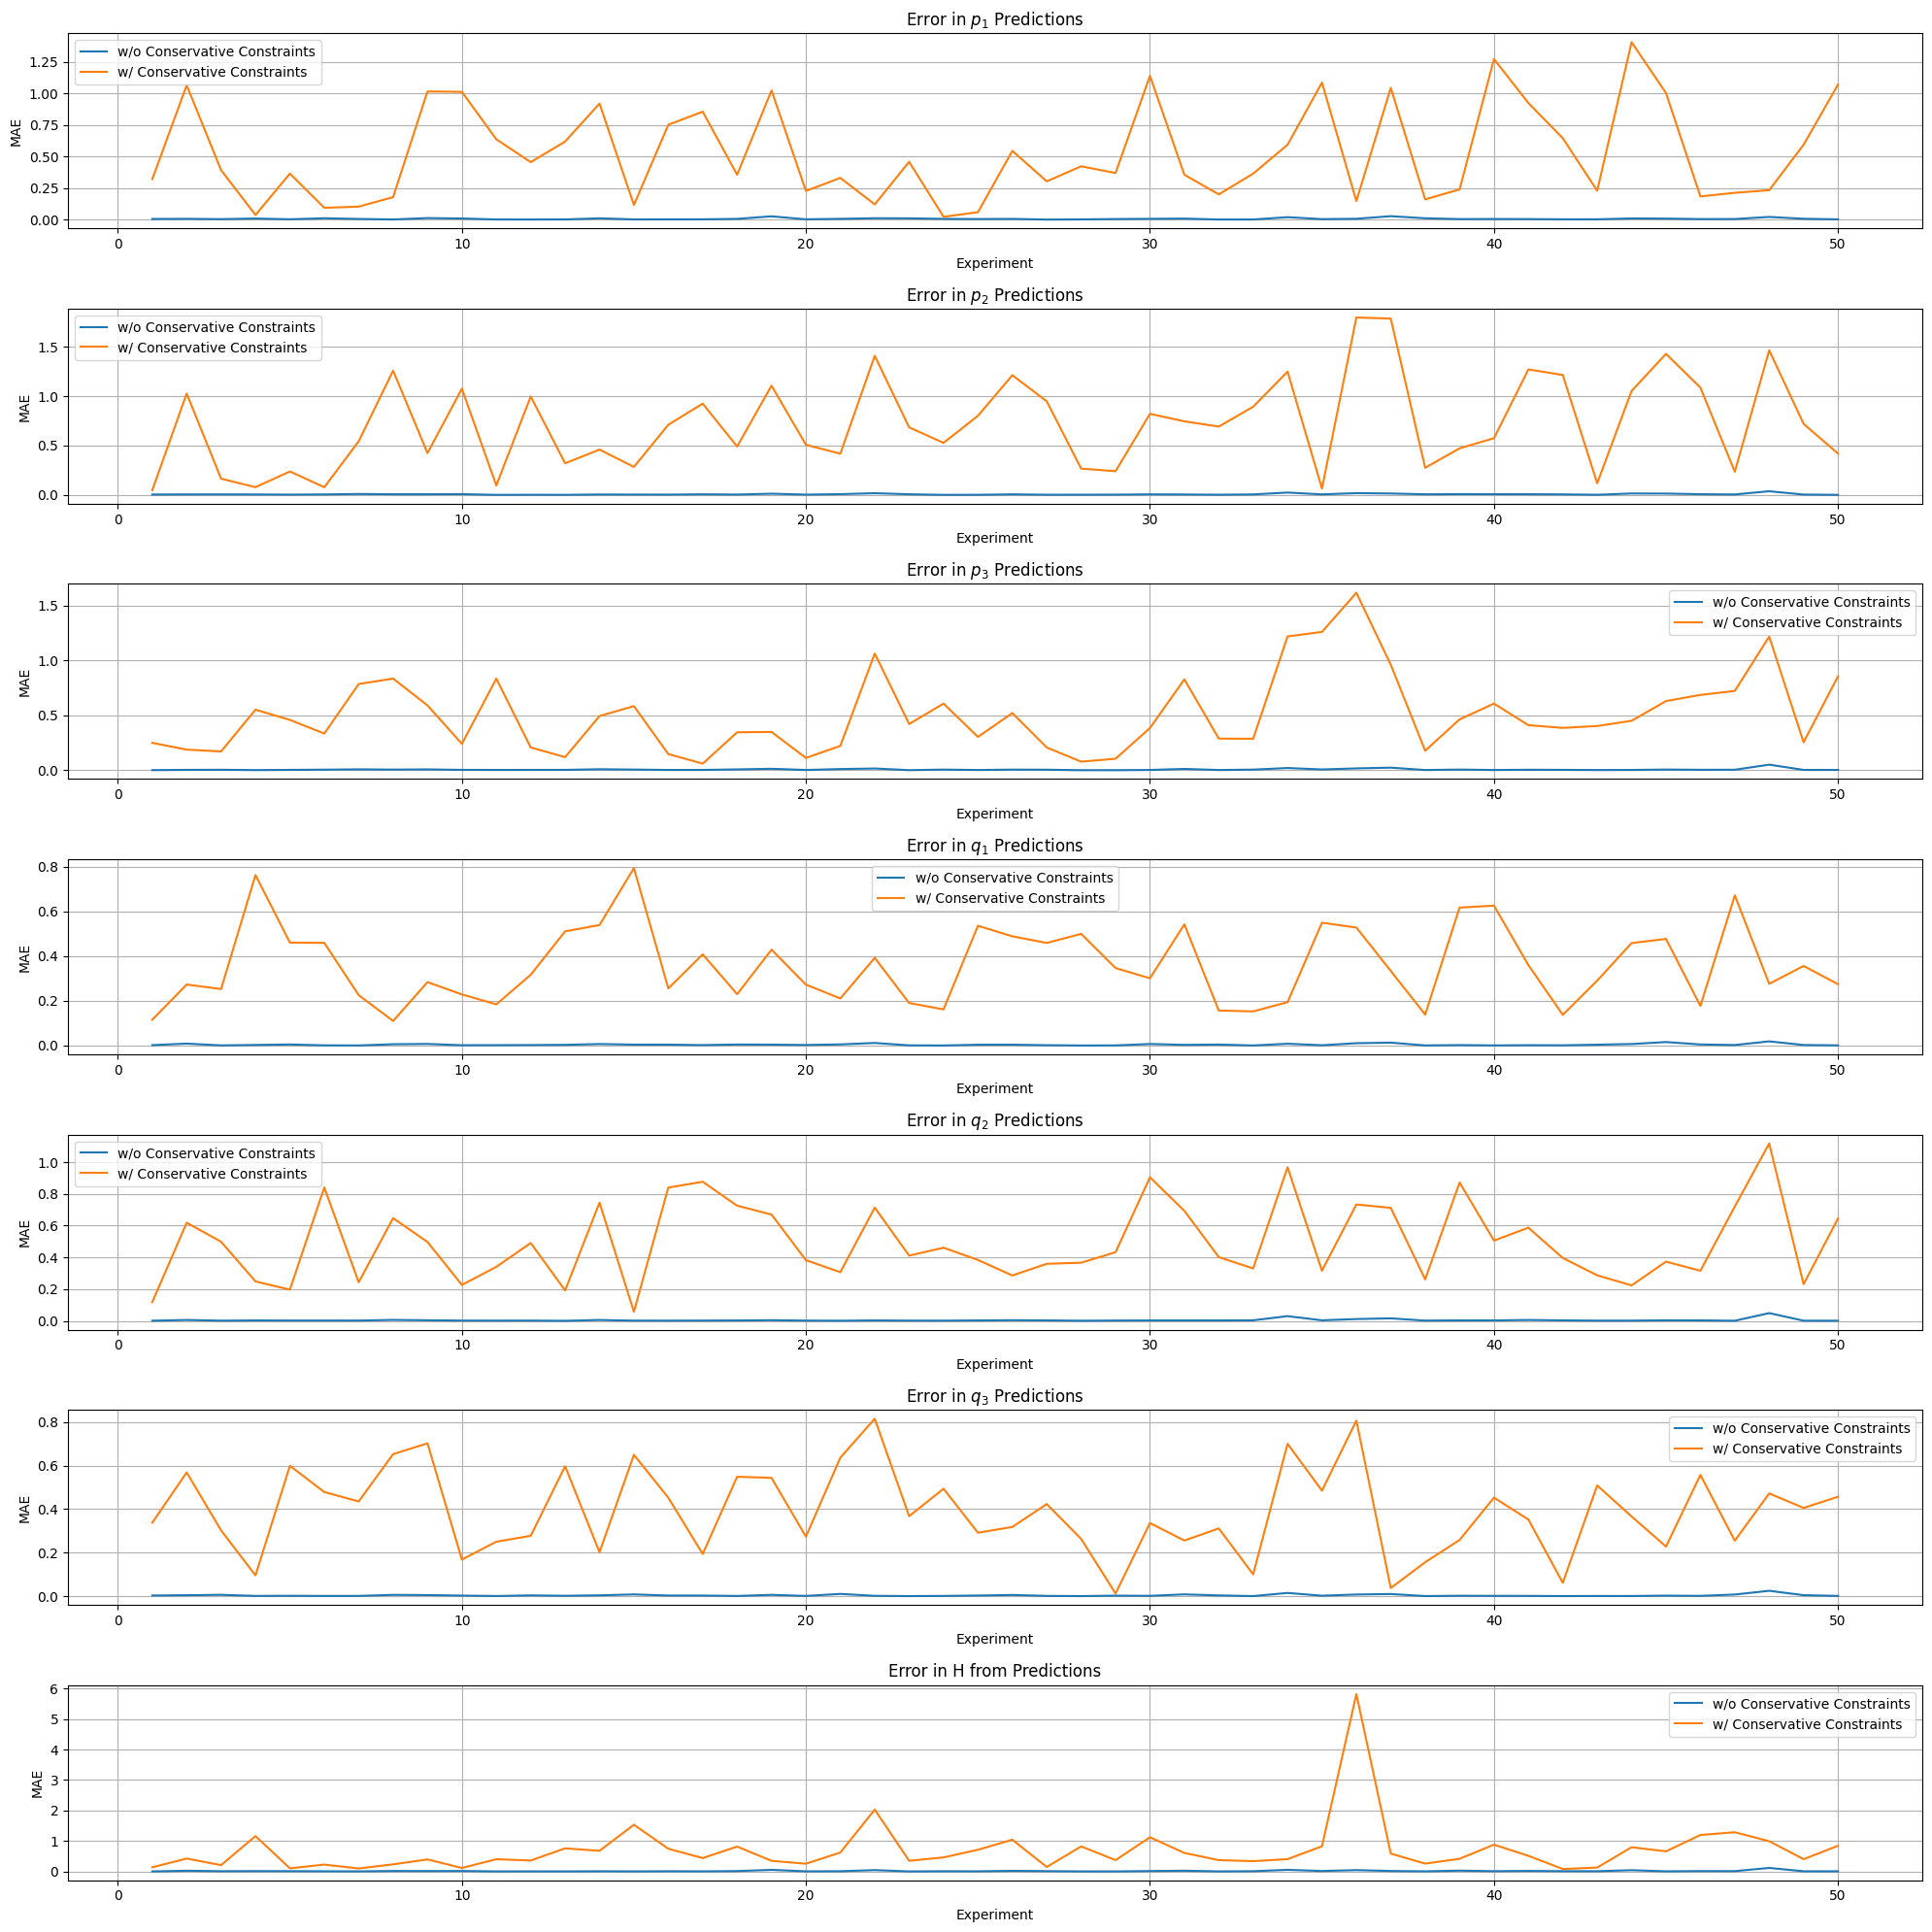

In [82]:
def run_test(num_vars, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
        
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
                
        tHE_model = np.column_stack([t, H_model, E_model])
                
        data_rk = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - 1) :


                val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)
                preds[i, j, k] = val

                
            preds[i, j, 6] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                    preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])

            # if j in bfgs_lst :
                
            #     args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
            #     H_arr = tH_model[:, 1:]
        
            #     xbfgs = find_min_bfgs(args_arr, H_arr)                

            #     for l in range(4) :

            #         preds[i, j, l] = xbfgs[:, l]

                
            #     preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])  
              

            for m in range(num_vars - 1) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 6] = np.mean(np.abs(H_rk - preds[i, j, 6]))
            


    fig = plt.figure(figsize=(20, 20))
    #fig.suptitle('Predictions of Vanilla DN with Conservative Soft Constrainints for a Series of Random Initial Conditions')
    #fig.tight_layout()

    num = [number + 1 for number in range(num_exp)]
    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$q_1$', r'$q_2$', r'$q_3$', 'H'] 

    for i in range(num_models) :
        
        for j in range(num_vars) :

            plt.subplot(num_vars, 1, j + 1)
            plt.plot(num, preds_error[:, i, j], label = labels_lst[i])
            plt.tight_layout()
            plt.legend()
            plt.ylabel("MAE")
            plt.xlabel("Experiment")

            if j == 6 :
                plt.title("Error in " + x_labels[j] + " from Predictions")
            else:
                plt.title("Error in " + x_labels[j] + " Predictions")
            plt.grid(visible = True)

    plt.show()

    

    
    #fig.savefig('DoublePend_consconstraints_mae_5000ep_50exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk)


preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk) = run_test(num_vars = 7, num_models = 2, num_exp = 50, \
         models_lst = [var_model, Evar_model], \
         params_lst = [params, Eparams], \
         labels_lst = ['w/o Conservative Constraints', 'w/ Conservative Constraints'], \
         bfgs_lst = [])

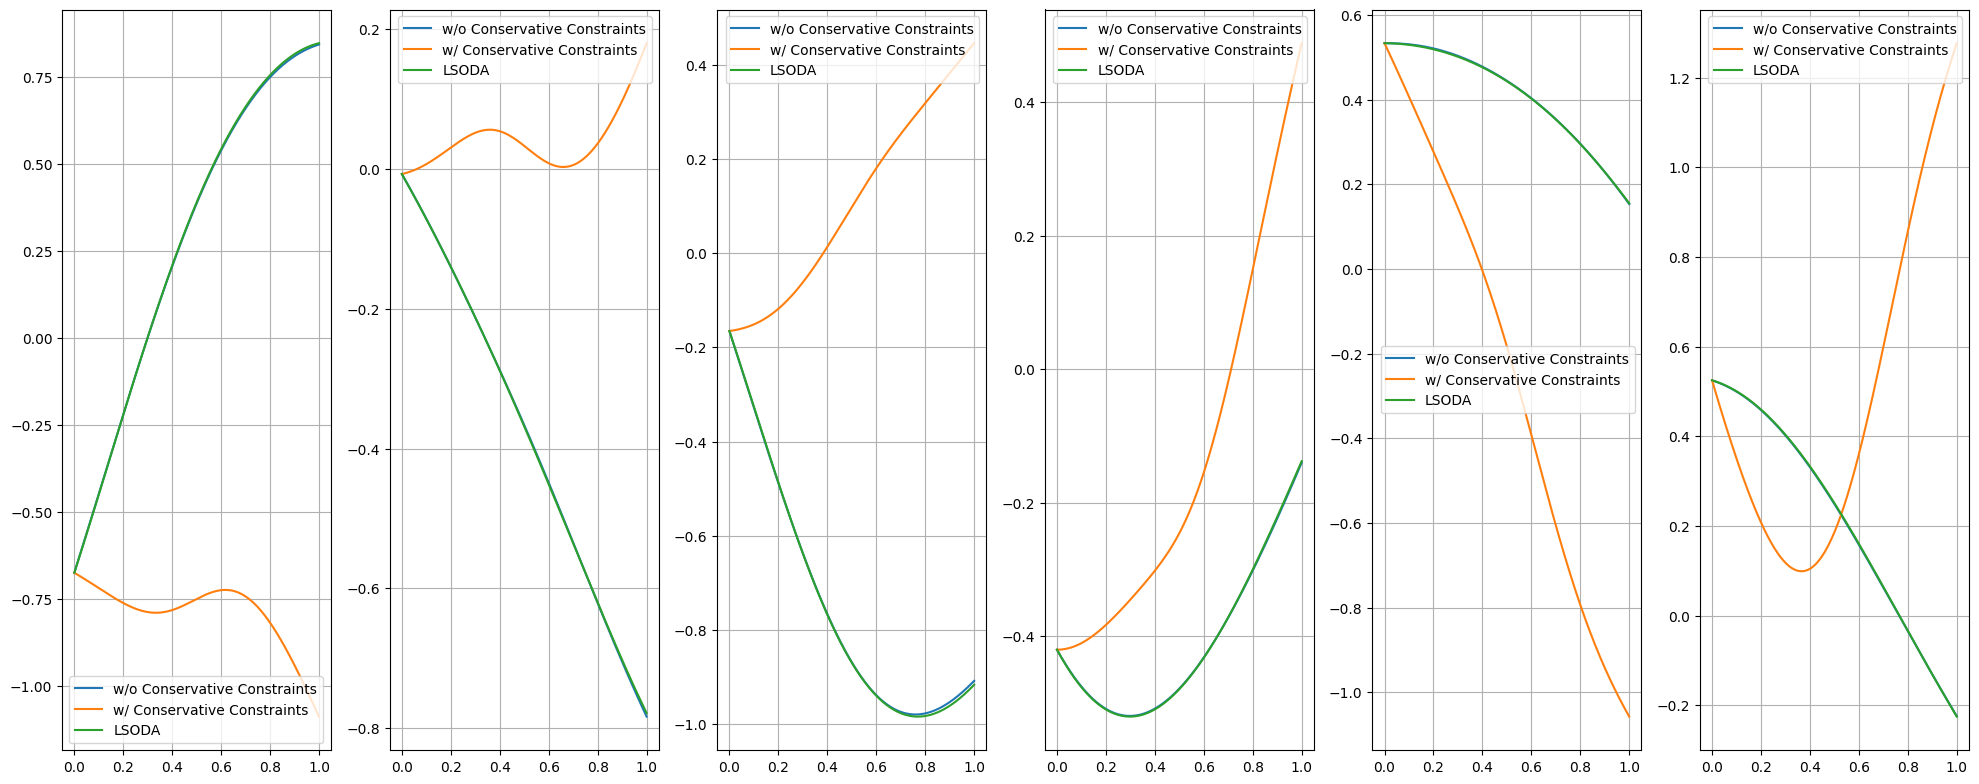

In [83]:
p1, p2, p3, q1, q2, q3, H = preds[-1, 0, 0, :], preds[-1, 0, 1, :], preds[-1, 0, 2, :], \
                            preds[-1, 0, 3, :], preds[-1, 0, 4, :], preds[-1, 0, 5, :], \
                            preds[-1, 0, 6, :]

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[-1, 1, 0, :], preds[-1, 1, 1, :], preds[-1, 1, 2, :], \
                                   preds[-1, 1, 3, :], preds[-1, 1, 4, :], preds[-1, 1, 5, :], \
                                   preds[-1, 1, 6, :]



fig = plt.figure(figsize=(20, 8))

plt.subplot(1, 6, 1)
plt.tight_layout()
plt.plot(t, p1)
plt.plot(t, Ep1)
plt.plot(t, p1_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])


plt.subplot(1, 6, 2)
plt.tight_layout()
plt.plot(t, p2)
plt.plot(t, Ep2)
plt.plot(t, p2_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])

plt.subplot(1, 6, 3)
plt.tight_layout()
plt.plot(t, p3)
plt.plot(t, Ep3)
plt.plot(t, p3_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])

plt.subplot(1, 6, 4)
plt.tight_layout()
plt.plot(t, q1)
plt.plot(t, Eq1)
plt.plot(t, q1_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])

plt.subplot(1, 6, 5)
plt.tight_layout()
plt.plot(t, q2)
plt.plot(t, Eq2)
plt.plot(t, q2_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])

plt.subplot(1, 6, 6)
plt.tight_layout()
plt.plot(t, q3)
plt.plot(t, Eq3)
plt.plot(t, q3_rk)
plt.grid()
plt.legend(['w/o Conservative Constraints', 'w/ Conservative Constraints', 'LSODA'])

In [84]:
@jax.jit
def f_func_newton_eig(args, e_0) :

    args = jnp.reshape(args, (-1,))
    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]
    
    evals = calc_evals_pq(p1, p2, p3, q1, q2, q3)

    e1, e2, e3 = evals[0], evals[1], evals[2]

    f1 = e1 - e1_0
    f2 = e2 - e2_0
    f3 = e3 - e3_0

    f = jnp.array([[f1], [f2], [f3]])
    f = jnp.reshape(f, (3, 1))

    return f
    
@jax.jit
def get_derivs_newton_eig(args, e_0, e) :

    a1, a2, a3, b1, b2, b3 = args[0], args[1], args[2], args[3], args[4], args[5]

    dF_e = 3*e**2 - 2*(a1 + a2 + a3)*e + (a1*a2 + a2*a3 + a1*a3 - b1**2 - b2**2 - b3**2)
    dF_a1 = -e**2 + (a2 + a3)*e - (a2*a3 - b2**2)
    dF_a2 = -e**2 + (a1 + a3)*e - (a1*a3 - b3**2)
    dF_a3 = -e**2 + (a1 + a2)*e - (a1*a2 - b1**2)
    dF_b1 = -2*b1*e - (-2*a3*b1 + 2*b2*b3)
    dF_b2 = -2*b2*e - (-2*a1*b2 + 2*b1*b3)
    dF_b3 = -2*b3*e - (-2*a2*b3 + 2*b1*b2)

    de_a1 = -dF_a1/dF_e
    de_a2 = -dF_a2/dF_e
    de_a3 = -dF_a3/dF_e
    de_b1 = -dF_b1/dF_e
    de_b2 = -dF_b2/dF_e
    de_b3 = -dF_b3/dF_e

    df_a1 = de_a1
    df_a2 = de_a2
    df_a3 = de_a3
    df_b1 = de_b1
    df_b2 = de_b2
    df_b3 = de_b3

    df_x = (df_a1, df_a2, df_a3, df_b1, df_b2, df_b3)

    return df_x


@jax.jit
def gradf_func_newton_eig(args, e_0) :

    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    e1_0, e2_0, e3_0 = e_0[0], e_0[1], e_0[2]

    a1, a2, a3, b1, b2, b3 = calc_ab(p1, p2, p3, q1, q2, q3)
    args_new = (a1, a2, a3, b1, b2, b3)
    
    evals = calc_evals_pq(p1, p2, p3, q1, q2, q3)
    
    e1, e2, e3 = evals[0], evals[1], evals[2]
 
    df1_a1, df1_a2, df1_a3, df1_b1, df1_b2, df1_b3 = get_derivs_newton_eig(args_new, e1_0, e1)
    df2_a1, df2_a2, df2_a3, df2_b1, df2_b2, df2_b3 = get_derivs_newton_eig(args_new, e2_0, e2)
    df3_a1, df3_a2, df3_a3, df3_b1, df3_b2, df3_b3 = get_derivs_newton_eig(args_new, e3_0, e3)

    df1_p1, df2_p1, df3_p1 = df1_a1*-0.5, df2_a1*-0.5, df3_a1*-0.5
    df1_p2, df2_p2, df3_p2 = df1_a2*-0.5, df2_a2*-0.5, df3_a2*-0.5
    df1_p3, df2_p3, df3_p3 = df1_a3*-0.5, df2_a3*-0.5, df3_a3*-0.5

    df1_q1 = df1_b1*0.5*b1 + df1_b3*-0.5*b3
    df2_q1 = df2_b1*0.5*b1 + df2_b3*-0.5*b3
    df3_q1 = df3_b1*0.5*b1 + df3_b3*-0.5*b3

    df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
    df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2
    df3_q2 = df3_b1*-0.5*b1 + df3_b2*0.5*b2

    df1_q3 = df1_b2*-0.5*b2 + df1_b3*0.5*b3
    df2_q3 = df2_b2*-0.5*b2 + df2_b3*0.5*b3
    df3_q3 = df3_b2*-0.5*b2 + df3_b3*0.5*b3

    gradf = jnp.array([[df1_p1, df1_p2, df1_p3, df1_q1, df1_q2, df1_q3],
                       [df2_p1, df2_p2, df2_p3, df2_q1, df2_q2, df2_q3],
                       [df3_p1, df3_p2, df3_p3, df3_q1, df3_q2, df3_q3]])

    gradf = jnp.reshape(gradf, (3, 6))
                    
    return gradf
    
@jax.jit

def newtons_eig_root(x, e_0) :

    iter_num = 0

    e_0 = jnp.reshape(e_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_eig(x, e_0)
        J = gradf_func_newton_eig(x, e_0)
        J_inv = jnp.linalg.pinv(J)

        print(x.shape, F.shape, J.shape, J_inv.shape)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

@jax.jit
def find_min_newton_eig(x, e_0) :

    return jnp.squeeze(jax.vmap(newtons_eig_root, (0, 0))(x, e_0))

In [85]:
x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]])
e_test = jnp.array([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0]])

print(calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0))

sol_newton_eig = find_min_newton_eig(x_test, e_test)

p1N, p2N, p3N, q1N, q2N, q3N = sol_newton_eig[0, 0], sol_newton_eig[0, 1], sol_newton_eig[0, 2], \
                               sol_newton_eig[0, 3], sol_newton_eig[0, 4], sol_newton_eig[0, 5]

print(p1N, p2N, p3N, q1N, q2N, q3N, calc_H(p1N, p2N, p3N, q1N, q2N, q3N))

15.124814981273536
(6, 1) (3, 1) (3, 6) (6, 3)
(6, 1) (3, 1) (3, 6) (6, 3)
(6, 1) (3, 1) (3, 6) (6, 3)
(6, 1) (3, 1) (3, 6) (6, 3)
(6, 1) (3, 1) (3, 6) (6, 3)
-4.620294000520717 -4.4979320346631475 -2.8817739648161385 4.794299629129233 5.555518509429018 4.650181861441748 28.747211971387205


In [86]:
@jax.jit
def f_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    H_0 = H_0[0]
    
    H = calc_H(p1, p2, p3, q1, q2, q3)

    f_val = H - H_0
    
    f = jnp.array([[f_val]])

    return f
    
@jax.jit
def gradf_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    H_0 = H_0[0]    

    dH_p1 = p1
    dH_p2 = p2
    dH_p3 = p3
    dH_q1 = jnp.exp(q1 - q2) - jnp.exp(q3 - q1)
    dH_q2 = -jnp.exp(q1 - q2) + jnp.exp(q2 - q3)
    dH_q3 = -jnp.exp(q2 - q3) + jnp.exp(q3 - q1)

    df_p1 = dH_p1
    df_p2 = dH_p2
    df_p3 = dH_p3
    df_q1 = dH_q1
    df_q2 = dH_q2
    df_q3 = dH_q3

    grad_f = jnp.array([[df_p1, df_p2, df_p3, df_q1, df_q2, df_q3]])

    return grad_f


@jax.jit
def newtons_H_root(x, H_0) :

    iter_num = 0

    H_0 = jnp.reshape(H_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_H(x, H_0)
        J = gradf_func_newton_H(x, H_0)
        J_inv = jnp.linalg.pinv(J)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

@jax.jit
def find_min_newton_H(x, H_0) :

    return jnp.squeeze(jax.vmap(newtons_H_root, (0, 0), 0)(x, H_0))

In [87]:
x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]])
H_test = jnp.array([[1.0], [1.0]])

print(calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0), calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0))

sol_newton_H = find_min_newton_H(x_test, H_test)

p1N, p2N, p3N, q1N, q2N, q3N = sol_newton_H[0, 0], sol_newton_H[0, 1], sol_newton_H[0, 2], sol_newton_H[0, 3], sol_newton_H[0, 4], sol_newton_H[0, 5]

print(p1N, p2N, p3N, q1N, q2N, q3N, calc_H(p1N, p2N, p3N, q1N, q2N, q3N))

15.124814981273536 15.124814981273536
0.468321103353259 0.9366422067065189 1.4049633100597783 3.9599804893094657 5.0 6.040019510690534 10.246949428506635


In [88]:
class HClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_newton_H(inputs, self.H_0)
    
        return x_min

In [89]:
class HCDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    q1_0 = u[:, 3:4]
    q2_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, q1_0, q2_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q1 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q2 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_q1 = branch_net[:, 3*self.units:4*self.units]
    branch_q2 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])

    z = jnp.column_stack([p1, p2, p3, q1, q2, q3])
    z = HClosestPoint(H_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    p3 = z[2:3]
    q1 = z[3:4]
    q2 = z[4:5]
    q3 = z[5:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, p2, p3, q1, q2, q3

In [90]:
@partial(jax.jit, static_argnums=(2,))
def HCvar_model(t, z, component, params):
  return HCdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def HCvar(t, z, component, params):
  return jax.vmap(HCvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def HCvar_t(t, z, component, params):
  return jax.vmap(jax.grad(HCvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def HCloss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    q1_0 = z[:, 3:4]
    q2_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    p3 = var(tHE, z, 2, params)
    q1 = var(tHE, z, 3, params)
    q2 = var(tHE, z, 4, params)
    q3 = var(tHE, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dp3_tHE = var_t(tHE, z, 2, params)
    dq1_tHE = var_t(tHE, z, 3, params)
    dq2_tHE = var_t(tHE, z, 4, params)
    dq3_tHE = var_t(tHE, z, 5, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + \
                q2_t_loss_w*q2_t_loss + p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss
    
@jax.jit
def HCtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(HCloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def HCoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [91]:
def HCtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = HCtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = HCoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [92]:
HCdeeponet = HCDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)

HCparams = HCdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [93]:
HCparam_count = sum(x.size for x in jax.tree.leaves(HCparams))
print(HCparam_count)

26640


In [94]:
#HCparams = copy.deepcopy(params)

tree_info, shapes, _ = flatten_pytree(HCparams)
HCparams_flat = jnp.load("HC_t1.0_2500+2500_ep_Toda3.npy")
HCparams = reconstruct_pytree(tree_info, shapes, HCparams_flat)

In [95]:
# epochs = 2500
# HCparams, HCloss = HCtrain_network(HCparams, de_points, zsensors, epochs)

# plt.semilogy(HCloss)
# plt.grid()

In [96]:
# split = 2500
# num_ep = np.arange(0, split, 1)
# HCnum_ep = np.arange(split, split + epochs, 1)

# plt.semilogy(num_ep, loss)
# plt.semilogy(HCnum_ep, HCloss)
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error of CPI-DeepONet")
# plt.legend(['Extended DeepONet', 'CPI-DeepONet (Hamiltonian)'])
# plt.grid()
# #plt.savefig('Toda3_cpiH_loss_2500+2500ep.png')

In [97]:
# tree_info, shapes, HCparams_flat = flatten_pytree(HCparams)
# jnp.save("HC_t1.0_2500+2500_ep_Toda3", HCparams_flat)

In [98]:
class EClosestPoint(nn.Module):

    e_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_newton_eig(inputs, self.e_0)
    
        return x_min

In [99]:
class ECDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    q1_0 = u[:, 3:4]
    q2_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, q1_0, q2_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q1 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q2 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_q1 = branch_net[:, 3*self.units:4*self.units]
    branch_q2 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])

    z = jnp.column_stack([p1, p2, p3, q1, q2, q3])
    e_0 = jnp.column_stack([eval1_0, eval2_0, eval3_0])
      
    z = EClosestPoint(e_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    p3 = z[2:3]
    q1 = z[3:4]
    q2 = z[4:5]
    q3 = z[5:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, p2, p3, q1, q2, q3

In [100]:
@partial(jax.jit, static_argnums=(2,))
def ECvar_model(t, z, component, params):
  return ECdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def ECvar(t, z, component, params):
  return jax.vmap(ECvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def ECvar_t(t, z, component, params):
  return jax.vmap(jax.grad(ECvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def ECloss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    q1_0 = z[:, 3:4]
    q2_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    p3 = var(tHE, z, 2, params)
    q1 = var(tHE, z, 3, params)
    q2 = var(tHE, z, 4, params)
    q3 = var(tHE, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dp3_tHE = var_t(tHE, z, 2, params)
    dq1_tHE = var_t(tHE, z, 3, params)
    dq2_tHE = var_t(tHE, z, 4, params)
    dq3_tHE = var_t(tHE, z, 5, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + \
                q2_t_loss_w*q2_t_loss + p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss
    
@jax.jit
def ECtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(ECloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def ECoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [101]:
def ECtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = ECtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = ECoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [102]:
ECdeeponet = ECDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)

ECparams = ECdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [103]:
ECparam_count = sum(x.size for x in jax.tree.leaves(ECparams))
print(ECparam_count)

26640


In [104]:
# ECparams = copy.deepcopy(params)

tree_info, shapes, _ = flatten_pytree(ECparams)
ECparams_flat = jnp.load("EC_t1.0_2500+2500_ep_Toda3.npy")
ECparams = reconstruct_pytree(tree_info, shapes, ECparams_flat)

In [105]:
# epochs = 2500
# ECparams, ECloss = ECtrain_network(ECparams, de_points, zsensors, epochs)

# plt.semilogy(ECloss)
# plt.grid()

In [106]:
# split = 2500
# num_ep = np.arange(0, split, 1)
# ECnum_ep = np.arange(split, split + epochs, 1)

# plt.semilogy(num_ep, loss)
# plt.semilogy(ECnum_ep, ECloss)
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error of CPI-DeepONet")
# plt.legend(['Extended DeepONet', 'CPI-DeepONet (Eigenvalues)'])
# plt.grid()
# #plt.savefig('Toda3_cpiE_loss_2500+2500ep.png')

In [107]:
# tree_info, shapes, ECparams_flat = flatten_pytree(ECparams)
# jnp.save("EC_t1.0_2500+2500_ep_Toda3", ECparams_flat)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

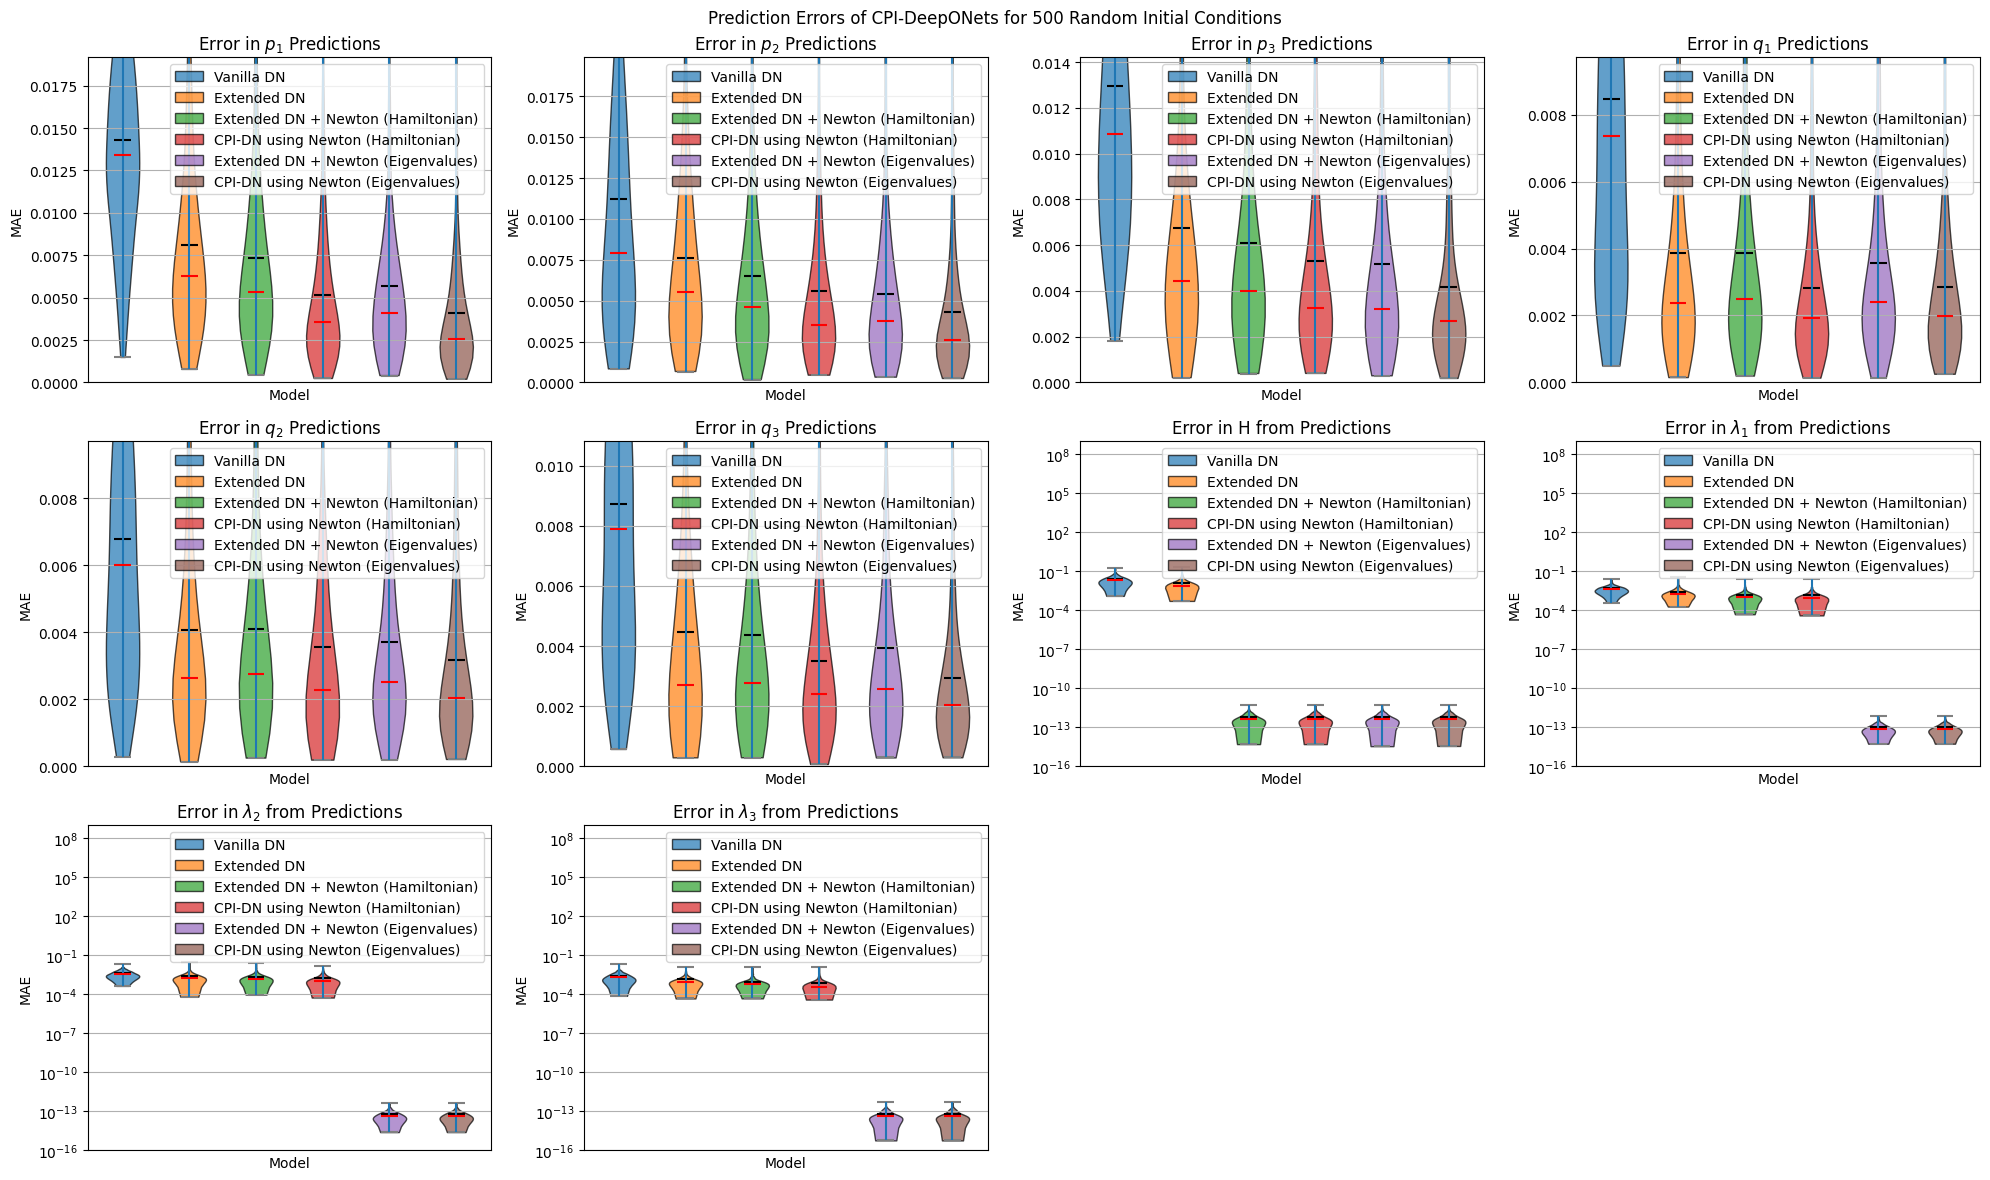

In [135]:
def run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst, newton_H_lst, newton_eig_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
        
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
                
        tHE_model = np.column_stack([t, H_model, E_model])
                
        data_rk = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        evals = jax.vmap(calc_evals_pq, (0), 0)(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        e1_rk, e2_rk, e3_rk = evals[:, 0], evals[:, 1], evals[:, 2]
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - num_cons) :


                val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)
                preds[i, j, k] = val

                
            preds[i, j, 6] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                    preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])


            evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                                    preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])
            
            preds[i, j, 7], preds[i, j, 8], preds[i, j, 9] = evals[:, 0], evals[:, 1], evals[:, 2]

            # if j in bfgs_lst :
                
            #     args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
            #     H_arr = tH_model[:, 1:]
        
            #     xbfgs = find_min_bfgs(args_arr, H_arr)                

            #     for l in range(4) :

            #         preds[i, j, l] = xbfgs[:, l]

                
            #     preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])  


            if j in newton_H_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                            preds[i, j, 3], preds[i, j, 4], preds[i, j, 5]])
                
                H_arr = tHE_model[:, 1:2]
            
                xnewtonH = find_min_newton_H(args_arr, H_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtonH[:, l]
            
                
                preds[i, j, 6] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                        preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])
    
    
                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                                        preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])
                
                preds[i, j, 7], preds[i, j, 8], preds[i, j, 9] = evals[:, 0], evals[:, 1], evals[:, 2]
        
            
            if j in newton_eig_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                            preds[i, j, 3], preds[i, j, 4], preds[i, j, 5]])
                
                E_arr = tHE_model[:, 2:]
            
                xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtoneig[:, l]
            
                
                preds[i, j, 6] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                        preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])
    
    
                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], \
                                                        preds[i, j, 3], preds[i, j, 4], preds[i, j, 5])
                
                preds[i, j, 7], preds[i, j, 8], preds[i, j, 9] = evals[:, 0], evals[:, 1], evals[:, 2]
              

            for m in range(num_vars - num_cons) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 6] = np.mean(np.abs(H_rk - preds[i, j, 6]))
            preds_error[i, j, 7] = np.mean(np.abs(e1_rk - preds[i, j, 7]))
            preds_error[i, j, 8] = np.mean(np.abs(e2_rk - preds[i, j, 8]))
            preds_error[i, j, 9] = np.mean(np.abs(e3_rk - preds[i, j, 9]))
            


    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$q_1$', r'$q_2$', r'$q_3$', 'H', r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Prediction Errors of CPI-DeepONets for 500 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']    # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(3, 4, j + 1)


        q1 = np.percentile(preds_error[:, 1, j], 25)
        q3 = np.percentile(preds_error[:, 1, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 6:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label

        if j >= 6:
            plt.yscale('log')
            plt.ylim(10**(-16), 10**9)

    
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    # fig.savefig('Toda3_cpi_violinmae_2500+2500ep_500exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk, e1_rk, e2_rk, e3_rk)


preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk, e1_rk, e2_rk, e3_rk) = run_test(num_vars = 10, num_cons = 4, num_models = 6, \
         num_exp = 500, \
         models_lst = [Evar_model, var_model, var_model, HCvar_model, var_model, ECvar_model], \
         params_lst = [Eparams, params, params, HCparams, params, ECparams], \
         labels_lst = ['Vanilla DN', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
                       'CPI-DN using Newton (Hamiltonian)', 'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Eigenvalues)'], \
         bfgs_lst = [], 
         newton_H_lst = [2],
         newton_eig_lst = [4])

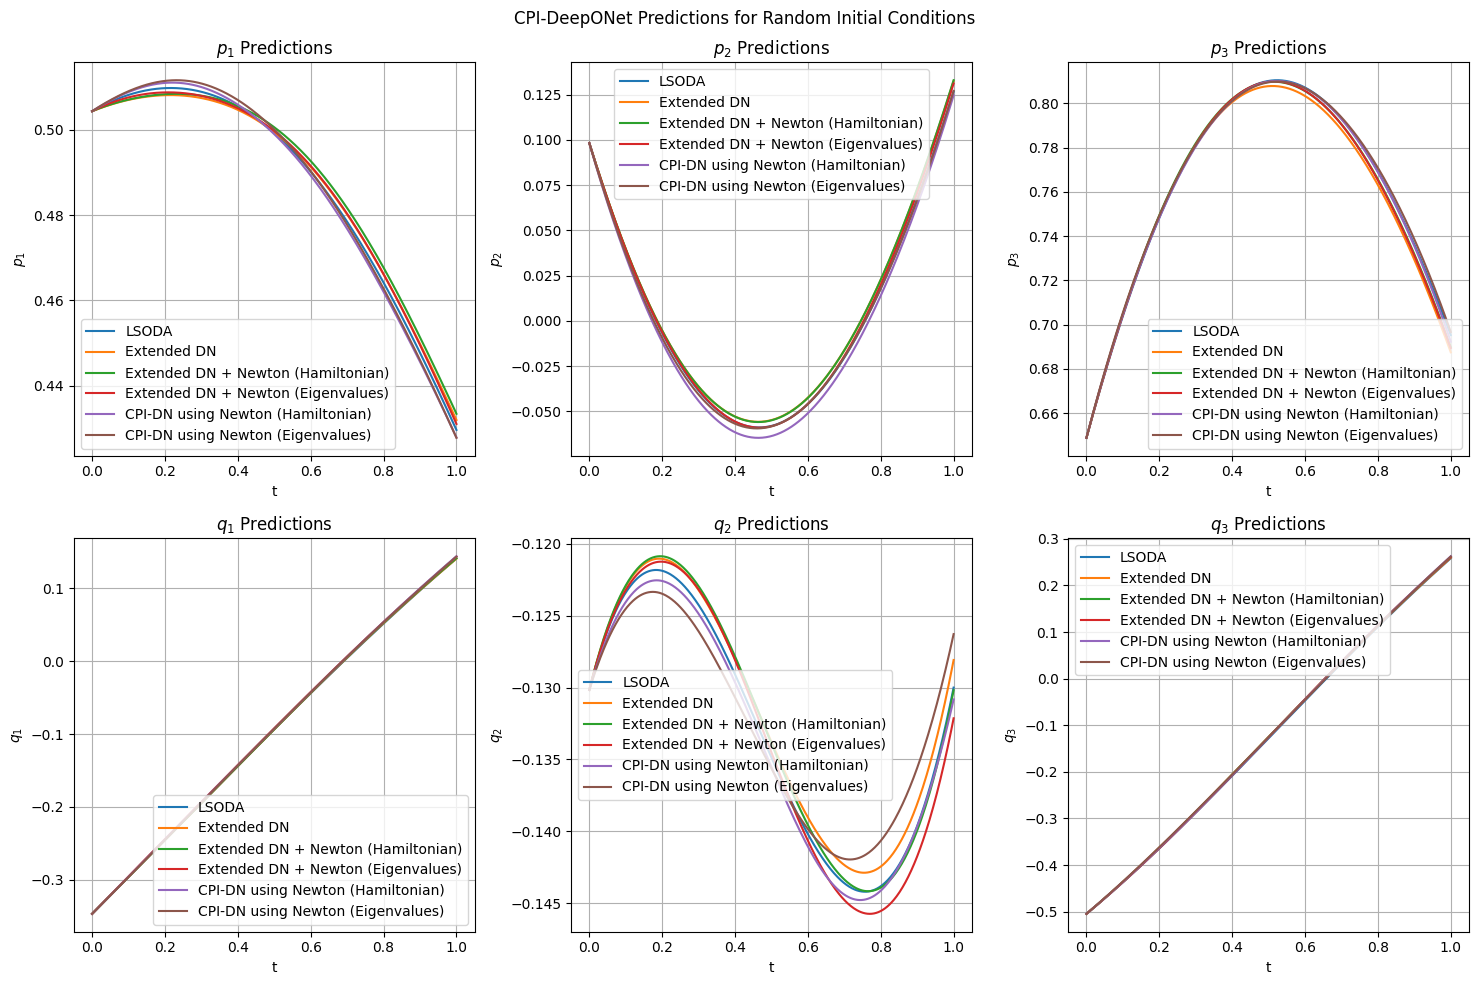

In [119]:
n = 500
t_tot = np.linspace(t0, tfinal, n)
model_no = -1
p1, p2, p3, q1, q2, q3, H = preds[model_no, 0, 0, :], preds[model_no, 0, 1, :], preds[model_no, 0, 2, :], \
                            preds[model_no, 0, 3, :], preds[model_no, 0, 4, :], preds[model_no, 0, 5, :], \
                            preds[model_no, 0, 6, :]

Hp1, Hp2, Hp3, Hq1, Hq2, Hq3, HH = preds[model_no, 1, 0, :], preds[model_no, 1, 1, :], preds[model_no, 1, 2, :], \
                                   preds[model_no, 1, 3, :], preds[model_no, 1, 4, :], preds[model_no, 1, 5, :], \
                                   preds[model_no, 1, 6, :]

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[model_no, 2, 0, :], preds[model_no, 2, 1, :], preds[model_no, 2, 2, :], \
                                   preds[model_no, 2, 3, :], preds[model_no, 2, 4, :], preds[model_no, 2, 5, :], \
                                   preds[model_no, 2, 6, :]


HCp1, HCp2, HCp3, HCq1, HCq2, HCq3, HCH = preds[model_no, 3, 0, :], preds[model_no, 3, 1, :], preds[model_no, 3, 2, :], \
                                          preds[model_no, 3, 3, :], preds[model_no, 3, 4, :], preds[model_no, 3, 5, :], \
                                          preds[model_no, 3, 6, :]


ECp1, ECp2, ECp3, ECq1, ECq2, ECq3, ECH = preds[model_no, 4, 0, :], preds[model_no, 4, 1, :], preds[model_no, 4, 2, :], \
                                          preds[model_no, 4, 3, :], preds[model_no, 4, 4, :], preds[model_no, 4, 5, :], \
                                          preds[model_no, 4, 6, :]



fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig('Toda3_cpi_preds_2500+2500ep.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

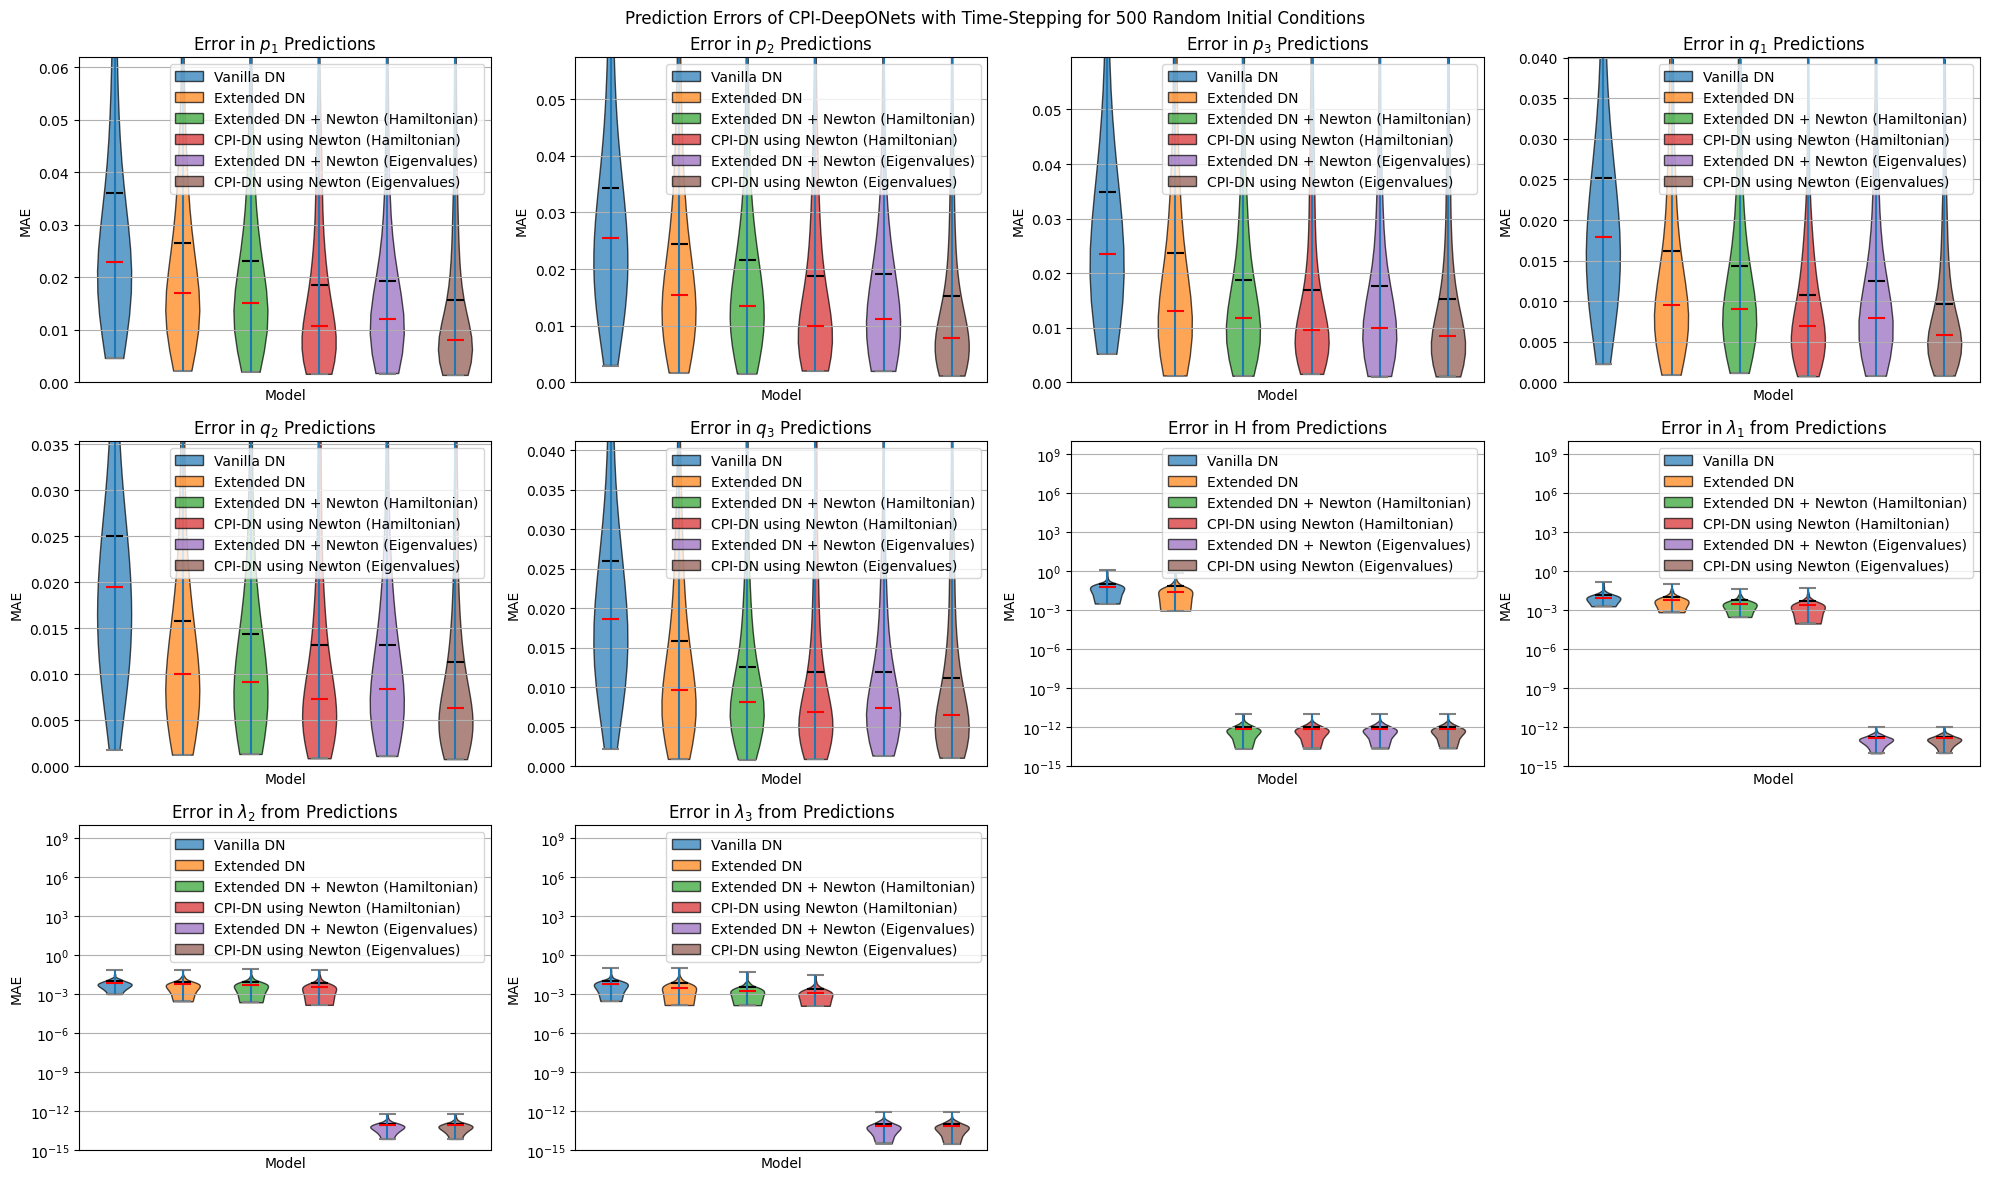

In [138]:
def tt_run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, newton_H_lst, newton_eig_lst, bfgs_lst, t_end) :

    n = 500

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    
    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

        t = np.linspace(t0, tfinal, n)
                
        tHE_model_0 = np.column_stack([t, H_model, E_model])
                        
        data_rk = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
        
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        evals = jax.vmap(calc_evals_pq, (0), 0)(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        e1_rk, e2_rk, e3_rk = evals[:, 0], evals[:, 1], evals[:, 2]
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]


            for c in range(num_cycles) :

                if c != 0 :

                    p1_init = preds[i, j, c - 1, 0, -1]
                    p2_init = preds[i, j, c - 1, 1, -1]
                    p3_init = preds[i, j, c - 1, 2, -1]
                    q1_init = preds[i, j, c - 1, 3, -1]
                    q2_init = preds[i, j, c - 1, 4, -1]
                    q3_init = preds[i, j, c - 1, 5, -1]
                    H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
                    evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
                    e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
                    
                    data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
                    data_model = np.reshape(data_model, (-1,))
                    data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
            
                    H_model = np.repeat(np.expand_dims(H_init, axis=0), n + 1, axis=0)
                    
                    E_model = np.column_stack([e1_init, e2_init, e3_init])
                    E_model = np.reshape(E_model, (-1,))
                    E_model = np.repeat(np.expand_dims(E_model, axis=0), n + 1, axis=0)

                    t = np.linspace(t0, tfinal + t_step, n + 1)
                            
                    tHE_model = np.column_stack([t, H_model, E_model])  

                else:

                    data_model = data_model_0
                    tHE_model = tHE_model_0

                
                for k in range(num_vars - num_cons) :
    
                    val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val                        
    
                preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                           preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])


                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                           preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])
            
                preds[i, j, c, 7], preds[i, j, c, 8], preds[i, j, c, 9] = evals[:, 0], evals[:, 1], evals[:, 2]



                if j in newton_H_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                                preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5]])
                    
                    H_arr = tHE_model[:, 1:2] if c == 0 else tHE_model[1:, 1:2]
            
                    xnewtonH = find_min_newton_H(args_arr, H_arr)                
    
                    for l in range(num_vars - num_cons) :
    
                        preds[i, j, c, l] = xnewtonH[:, l]
    
                    
                    preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])
    
    
                    evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])
                
                    preds[i, j, c, 7], preds[i, j, c, 8], preds[i, j, c, 9] = evals[:, 0], evals[:, 1], evals[:, 2]


                if j in newton_eig_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                                preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5]])
                    
                    E_arr = tHE_model[:, 2:] if c == 0 else tHE_model[1:, 2:]
            
                    xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
    
                    for l in range(num_vars - num_cons) :
    
                        preds[i, j, c, l] = xnewtoneig[:, l]
    
                    
                    preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])
    
    
                    evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])
                
                    preds[i, j, c, 7], preds[i, j, c, 8], preds[i, j, c, 9] = evals[:, 0], evals[:, 1], evals[:, 2]

                                     
    
            for m in range(num_vars - num_cons) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 6] = np.mean(np.abs(H_rk - preds[i, j, :, 6].flatten()))
            preds_error[i, j, 7] = np.mean(np.abs(e1_rk - preds[i, j, :, 7].flatten()))
            preds_error[i, j, 8] = np.mean(np.abs(e2_rk - preds[i, j, :, 8].flatten()))
            preds_error[i, j, 9] = np.mean(np.abs(e3_rk - preds[i, j, :, 9].flatten()))
            
            


    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$q_1$', r'$q_2$', r'$q_3$', 'H', r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Prediction Errors of CPI-DeepONets with Time-Stepping for 500 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']    # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(3, 4, j + 1)


        q1 = np.percentile(preds_error[:, 1, j], 25)
        q3 = np.percentile(preds_error[:, 1, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 6:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label

        if j >= 6:
            plt.yscale('log')
            plt.ylim(10**(-15), 10**10)

    
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    # fig.savefig('Toda3_tt_3.0_cpi_violinmae_2500+2500ep_500exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk, e1_rk, e2_rk, e3_rk)


t_end_val = 3.0

preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk, e1_rk, e2_rk, e3_rk) = tt_run_test(num_vars = 10, num_cons = 4, num_models = 6, \
         num_exp = 500, \
         models_lst = [Evar_model, var_model, var_model, HCvar_model, var_model, ECvar_model], \
         params_lst = [Eparams, params, params, HCparams, params, ECparams], \
         labels_lst = ['Vanilla DN', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
                       'CPI-DN using Newton (Hamiltonian)', 'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Eigenvalues)'], \
         bfgs_lst = [], 
         newton_H_lst = [2],
         newton_eig_lst = [4],
         t_end = t_end_val)

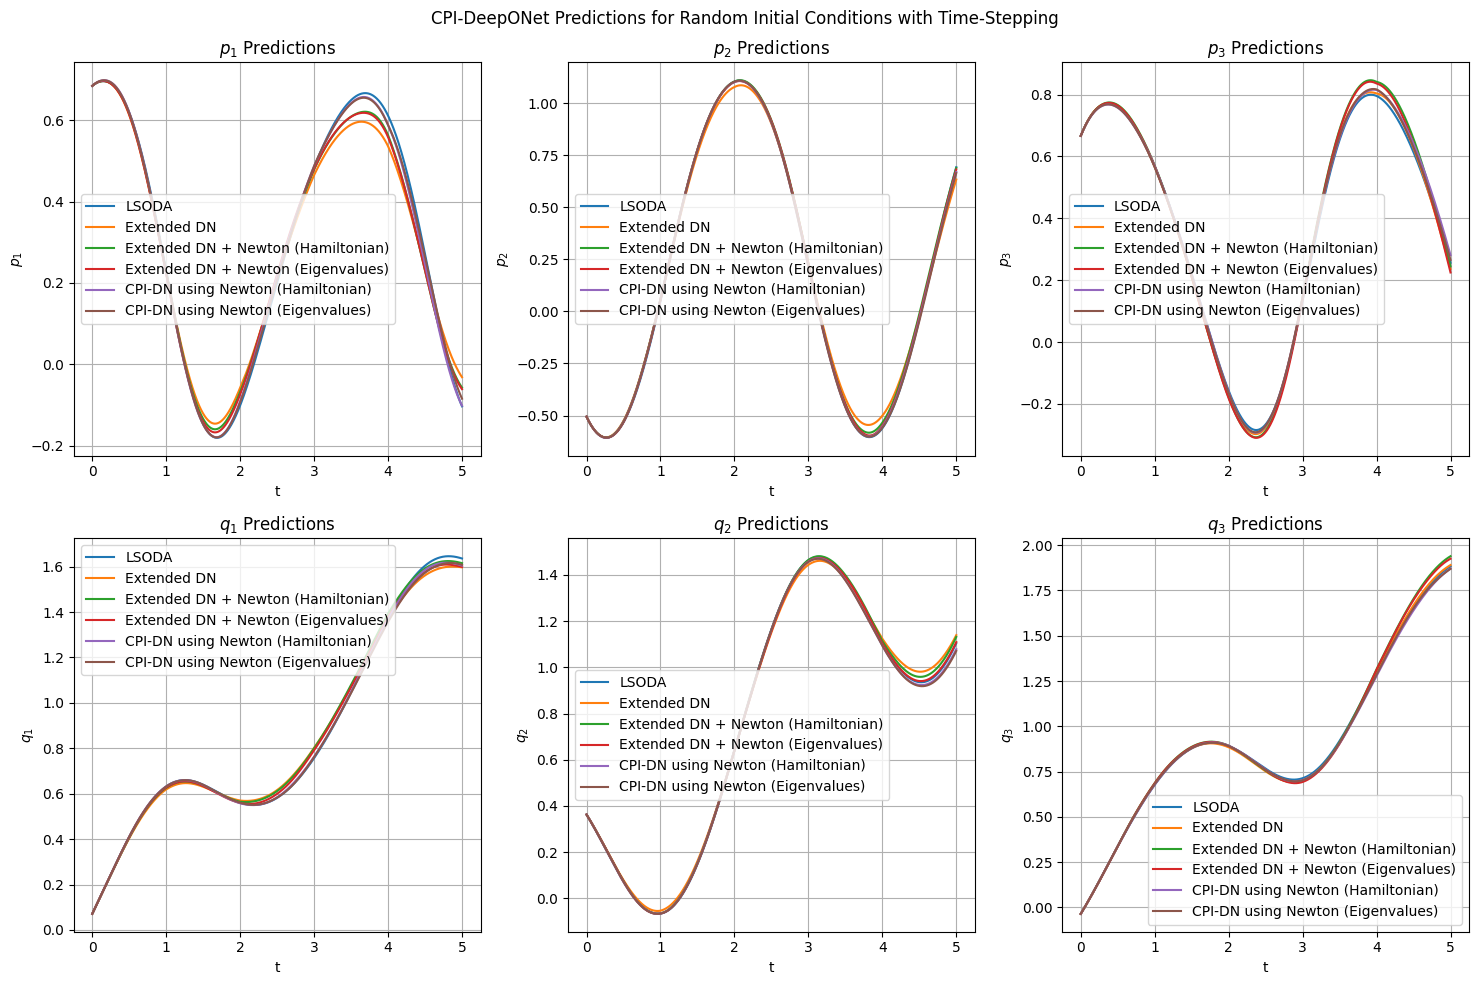

In [156]:
n = 500
t_end = t_end_val

num_cycles = int(t_end/tfinal)
n_tot = n*num_cycles
t_tot = np.linspace(t0, t_end, n_tot)

model_no = -1

p1, p2, p3, q1, q2, q3, H = preds[model_no, 0, :, 0, :].flatten(), preds[model_no, 0, :, 1, :].flatten(), preds[model_no, 0, :, 2, :].flatten(), \
                            preds[model_no, 0, :, 3, :].flatten(), preds[model_no, 0, :, 4, :].flatten(), preds[model_no, 0, :, 5, :].flatten(), \
                            preds[model_no, 0, :, 6, :].flatten()

Hp1, Hp2, Hp3, Hq1, Hq2, Hq3, HH = preds[model_no, 1, :, 0, :].flatten(), preds[model_no, 1, :, 1, :].flatten(), preds[model_no, 1, :, 2, :].flatten(), \
                                   preds[model_no, 1, :, 3, :].flatten(), preds[model_no, 1, :, 4, :].flatten(), preds[model_no, 1, :, 5, :].flatten(), \
                                   preds[model_no, 1, :, 6, :].flatten()

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[model_no, 2, :, 0, :].flatten(), preds[model_no, 2, :, 1, :].flatten(), preds[model_no, 2, :, 2, :].flatten(), \
                                   preds[model_no, 2, :, 3, :].flatten(), preds[model_no, 2, :, 4, :].flatten(), preds[model_no, 2, :, 5, :].flatten(), \
                                   preds[model_no, 2, :, 6, :].flatten()


HCp1, HCp2, HCp3, HCq1, HCq2, HCq3, HCH = preds[model_no, 3, :, 0, :].flatten(), preds[model_no, 3, :, 1, :].flatten(), preds[model_no, 3, :, 2, :].flatten(), \
                                          preds[model_no, 3, :, 3, :].flatten(), preds[model_no, 3, :, 4, :].flatten(), preds[model_no, 3, :, 5, :].flatten(), \
                                          preds[model_no, 3, :, 6, :].flatten()


ECp1, ECp2, ECp3, ECq1, ECq2, ECq3, ECH = preds[model_no, 4, :, 0, :].flatten(), preds[model_no, 4, :, 1, :].flatten(), preds[model_no, 4, :, 2, :].flatten(), \
                                          preds[model_no, 4, :, 3, :].flatten(), preds[model_no, 4, :, 4, :].flatten(), preds[model_no, 4, :, 5, :].flatten(), \
                                          preds[model_no, 4, :, 6, :].flatten()





fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions with Time-Stepping")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig("Toda3_cpi_preds_2500+2500ep.png")